In [1]:
import pandas as pd
import re
from collections import defaultdict
import numpy as np
# Path to the log file
log_file = f"./training_log.txt"

# Initialize lists to store data for each run
runs_data = []
baseline_metrics = defaultdict(list)

# Function to parse a single run
def parse_run(run_text):
    run_data = {}
    
    # Extract data split
    total_train = int(re.search(r'Total Training Data: (\d+)', run_text).group(1))
    labeled_train = int(re.search(r'Labeled Training Data: (\d+)', run_text).group(1))
    unlabeled_train = int(re.search(r'Unlabeled Training Data: (\d+)', run_text).group(1))
    
    # Extract active learning parameters
    budget_per_iter = int(re.search(r'Active Learning Budget per Iteration: (\d+)', run_text).group(1))
    max_iterations = int(re.search(r'Active Learning Max Iterations: (\d+)', run_text).group(1))
    data_labeled_al = budget_per_iter * max_iterations
    
    # Extract strategy
    strategy = re.search(r'Strategy for query/sample selection: (\w+)', run_text).group(1)
    uncertainty_mode = re.search(r'Uncertainty calculatin mode for uncertainty strategy \(mean/max/topk\): (\w+)', run_text)
    strategy_full = f"{strategy} ({uncertainty_mode.group(1)})" if uncertainty_mode else strategy
    
    # Extract active learning metrics
    al_metrics = {}
    al_metrics['IoU'] = float(re.search(r'Active Learning Model:.*?IoU: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Dice'] = float(re.search(r'Active Learning Model:.*?Dice: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Accuracy'] = float(re.search(r'Active Learning Model:.*?Accuracy: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Precision'] = float(re.search(r'Active Learning Model:.*?Precision: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Recall'] = float(re.search(r'Active Learning Model:.*?Recall: ([\d.]+)', run_text, re.DOTALL).group(1))
    
    # Extract baseline metrics
    baseline_metrics_run = {}
    baseline_metrics_run['IoU'] = float(re.search(r'Baseline Model:.*?IoU: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Dice'] = float(re.search(r'Baseline Model:.*?Dice: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Accuracy'] = float(re.search(r'Baseline Model:.*?Accuracy: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Precision'] = float(re.search(r'Baseline Model:.*?Precision: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Recall'] = float(re.search(r'Baseline Model:.*?Recall: ([\d.]+)', run_text, re.DOTALL).group(1))
    
    # Store baseline metrics for averaging
    for metric, value in baseline_metrics_run.items():
        baseline_metrics[metric].append(value)
    
    # Store run data
    run_data['Labeled Data'] = labeled_train
    run_data['Unlabeled Data'] = unlabeled_train
    run_data['Data Labeled (AL)'] = data_labeled_al
    run_data['Strategy'] = strategy_full
    run_data['IoU'] = al_metrics['IoU']
    run_data['Dice'] = al_metrics['Dice']
    run_data['Accuracy'] = al_metrics['Accuracy']
    run_data['Precision'] = al_metrics['Precision']
    run_data['Recall'] = al_metrics['Recall']
    
    return run_data

In [2]:
# Read and parse the log file
with open(log_file, 'r') as f:
    log_content = f.read()

# Split log into individual runs
runs = log_content.split('Run at ')[1:]  # Skip first split which is empty
for run in runs:
    run_data = parse_run(run)
    runs_data.append(run_data)

# Create DataFrame for active learning results
df = pd.DataFrame(runs_data)

# Calculate average baseline metrics
avg_baseline = {metric: sum(values) / len(values) for metric, values in baseline_metrics.items()}

# Add average baseline metrics as a separate row
baseline_row = {
    'Labeled Data': 2331,
    'Unlabeled Data': 'N/A',
    'Data Labeled (AL)': 'N/A',
    'Strategy': 'Baseline (Average)',
    'IoU': avg_baseline['IoU'],
    'Dice': avg_baseline['Dice'],
    'Accuracy': avg_baseline['Accuracy'],
    'Precision': avg_baseline['Precision'],
    'Recall': avg_baseline['Recall']
}
df = pd.concat([df, pd.DataFrame([baseline_row])], ignore_index=True)

# Calculate G-mean (sqrt(Precision * Recall))
df['G-mean'] = np.sqrt(df['Precision'] * df['Recall'])
df.loc[df['Strategy'].str.contains('model_change'), 'Strategy'] = 'model_change'

# Format the DataFrame for display
pd.set_option('display.float_format', '{:.4f}'.format)
# print("\nSummary of Training Runs:")
# print(df[['Labeled Data', 'Unlabeled Data', 'Data Labeled (AL)', 'Strategy', 
#          'AL IoU', 'AL Dice', 'AL Accuracy', 'AL Precision', 'AL Recall']])

# if __name__ == "__main__":
#     print("Summary generation complete.")

In [3]:
df

,Labeled Data,Unlabeled Data,Data Labeled (AL),Strategy,IoU,Dice,Accuracy,Precision,Recall,G-mean
0,1165,1166,500,uncertainty (mean),0.6677,0.7669,0.9986,0.8750,0.7548,0.8127
1,1748,583,500,uncertainty (mean),0.6623,0.7539,0.9989,0.8668,0.7625,0.8130
2,582,1749,1000,uncertainty (mean),0.6756,0.7685,0.9988,0.8780,0.7653,0.8197
3,582,1749,700,uncertainty (mean),0.6732,0.7639,0.9988,0.9139,0.7318,0.8178
4,1165,1166,500,model_change,0.6637,0.7591,0.9987,0.8866,0.7372,0.8085
5,1748,583,500,model_change,0.6421,0.7502,0.9989,0.8518,0.7521,0.8004
6,582,1749,1000,model_change,0.6586,0.7532,0.9985,0.8828,0.7385,0.8074
7,582,1749,700,model_change,0.6542,0.7532,0.9985,0.8140,0.7821,0.7979
8,2331,N/A,N/A,Baseline (Average),0.6390,0.7369,0.9986,0.8260,0.7593,0.7920


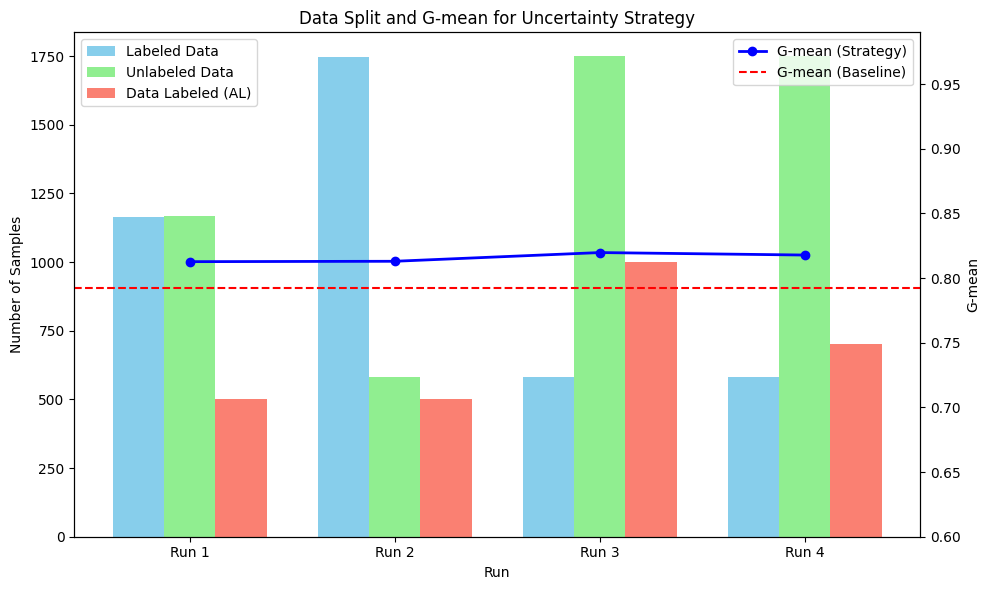

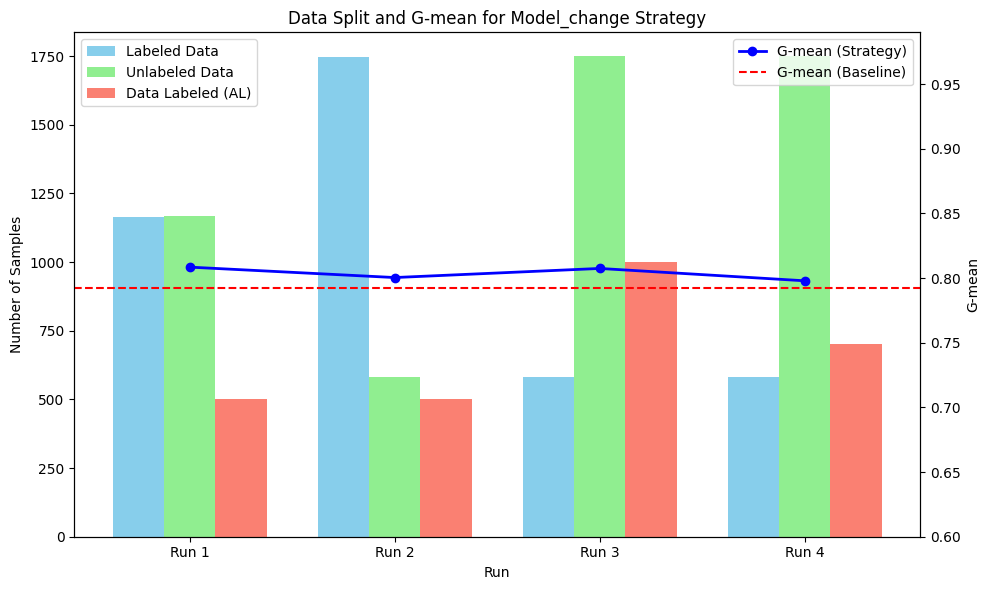

Visualizations generated and saved as 'uncertainty_strategy_plot.png' and 'model_change_strategy_plot.png'.


In [7]:
import matplotlib.pyplot as plt

df['Unlabeled Data'] = pd.to_numeric(df['Unlabeled Data'], errors='coerce')
df['Data Labeled (AL)'] = pd.to_numeric(df['Data Labeled (AL)'], errors='coerce')

baseline_gmean = df[df['Strategy'] == 'Baseline (Average)']['G-mean'].iloc[0]

def plot_strategy(df, strategy_name, baseline_gmean, save_path):
    if strategy_name == 'uncertainty':
        df_strategy = df[df['Strategy'].str.contains('uncertainty')]
    else:
        df_strategy = df[df['Strategy'].str.contains(strategy_name)]
    
    runs = range(len(df_strategy))
    labeled_data = df_strategy['Labeled Data']
    unlabeled_data = df_strategy['Unlabeled Data']
    al_data = df_strategy['Data Labeled (AL)']
    gmeans = df_strategy['G-mean']
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    bar_width = 0.25
    ax1.bar([r - bar_width for r in runs], labeled_data, width=bar_width, label='Labeled Data', color='skyblue')
    ax1.bar(runs, unlabeled_data, width=bar_width, label='Unlabeled Data', color='lightgreen')
    ax1.bar([r + bar_width for r in runs], al_data, width=bar_width, label='Data Labeled (AL)', color='salmon')
    
    ax1.set_xlabel('Run')
    ax1.set_ylabel('Number of Samples')
    ax1.set_title(f'Data Split and G-mean for {strategy_name.capitalize()} Strategy')
    ax1.set_xticks(runs)
    ax1.set_xticklabels([f'Run {i+1}' for i in runs])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(runs, gmeans, marker='o', color='blue', label='G-mean (Strategy)', linewidth=2)
    ax2.axhline(y=baseline_gmean, color='red', linestyle='--', label='G-mean (Baseline)')
    ax2.set_ylabel('G-mean')
    ax2.set_ylim(0.60, 0.99)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_strategy(df, 'uncertainty', baseline_gmean ,'uncertainty_strategy_plot.png'
             )
plot_strategy(df, 'model_change', baseline_gmean, 'model_change_strategy_plot.png'
             )

# if __name__ == "__main__":
#     print("Visualizations generated and saved as 'uncertainty_strategy_plot.png' and 'model_change_strategy_plot.png'.")